In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
# from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from scipy.stats import randint

In [2]:
df = pd.read_parquet("/Users/youssef/Documents/IMT/S6_IMT/UEF_Advanced_Machine_Learning/child-mind-institute-detect-sleep-states/Zzzs_train_multi.parquet")
print(df.head())


      series_id  step                 timestamp     anglez    enmo  awake
0  08db4255286f     0  2018-11-05T10:00:00-0400 -30.845301  0.0447      1
1  08db4255286f     1  2018-11-05T10:00:05-0400 -34.181801  0.0443      1
2  08db4255286f     2  2018-11-05T10:00:10-0400 -33.877102  0.0483      1
3  08db4255286f     3  2018-11-05T10:00:15-0400 -34.282101  0.0680      1
4  08db4255286f     4  2018-11-05T10:00:20-0400 -34.385799  0.0768      1


In [8]:
import numpy as np
import polars as pl
import pandas as pd

# 📌 Charger et transformer le dataset
train = (pl.scan_parquet("/Users/youssef/Documents/IMT/S6_IMT/UEF_Advanced_Machine_Learning/child-mind-institute-detect-sleep-states/Zzzs_train_multi.parquet")
          .with_columns(
              (pl.col("timestamp")
                 .str.strptime(pl.Datetime, "%Y-%m-%dT%H:%M:%S%Z")
                 .dt.hour()
                 .alias("hour")  # Extraire l'heure
              )
          )
          .drop("timestamp")  # Supprimer timestamp original
          .collect()
          .to_pandas()
)

# 📌 Ajouter encodage sinusoïdal du temps
train['hour_sin'] = np.sin(2 * np.pi * train['hour'] / 24)
train['hour_cos'] = np.cos(2 * np.pi * train['hour'] / 24)
train = train.drop(columns=['hour'])  # Supprimer la colonne brute
df = train.copy()
# 📌 Affichage des premières lignes
print(train.head())

      series_id  step     anglez    enmo  awake  hour_sin  hour_cos
0  08db4255286f     0 -30.845301  0.0447      1       0.5 -0.866025
1  08db4255286f     1 -34.181801  0.0443      1       0.5 -0.866025
2  08db4255286f     2 -33.877102  0.0483      1       0.5 -0.866025
3  08db4255286f     3 -34.282101  0.0680      1       0.5 -0.866025
4  08db4255286f     4 -34.385799  0.0768      1       0.5 -0.866025


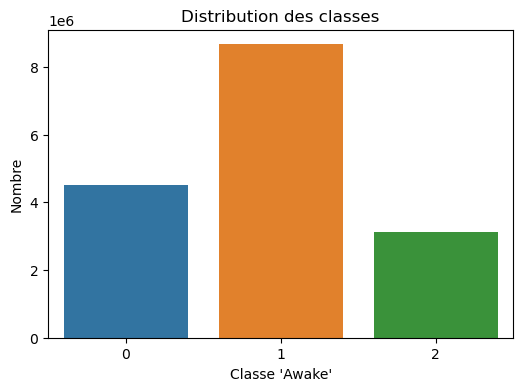

In [4]:
# Visualisation de la distribution des classes
y = df['awake']
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Distribution des classes")
plt.xlabel("Classe 'Awake'")
plt.ylabel("Nombre")
plt.show()

In [5]:
print(df.dtypes)


series_id     object
step          uint32
anglez       float32
enmo         float32
awake          int64
hour_sin     float64
hour_cos     float64
dtype: object


In [10]:
# 📌 Séparer les features (X) et la cible (y)
X = df.drop(columns=['awake', 'series_id'])
y = df['awake']

# 📌 Division en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 📌 Normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# from imblearn.over_sampling import SMOTE

# # Appliquer SMOTE pour équilibrer les classes
# smote = SMOTE(sampling_strategy='auto', random_state=42) # sampling_strategy='auto' pour augmenter la classe minoritaire jusqu'à égalité avec la classe majoritaire # random_state pour la reproductibilité (seed)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train) # # Appliquer SMOTE sur les données d'entraînement et créer de nouvelles données synthétiques

In [12]:
# 📌 Initialisation de KNN avec poids des voisins (plus de poids pour les voisins proches) et entraînement du modèle KNN
k = 5  # Choisir la valeur de k
knn = KNeighborsClassifier(n_neighbors=k, weights='distance') # Comment ça fonctionne ? Si un voisin est plus proche (par exemple, sa distance euclidienne est faible), il aura un poids plus élevé. Si un voisin est plus éloigné (avec une distance plus grande), il aura un poids plus faible. La prédiction est alors basée sur la somme des poids des classes des voisins, plutôt que simplement la majorité brute des classes des voisins.
knn.fit(X_train, y_train)

# 📌 Prédictions
y_pred = knn.predict(X_test)

# # 📌 Obtenir les probabilités de prédiction
# y_probs = knn.predict_proba(X_test)
# # Définir un seuil personnalisé (ex: 0.6 pour éveillé)
# seuil = 0.2
# y_pred = (y_probs[:, 1] >= seuil).astype(int)  # Classe "éveillé" si proba >= seuil

# 📌 Évaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy du modèle KNN: {accuracy:.2f}")

Accuracy du modèle KNN: 0.88


SMOTE, k = 5 et k = 11 : 0.84

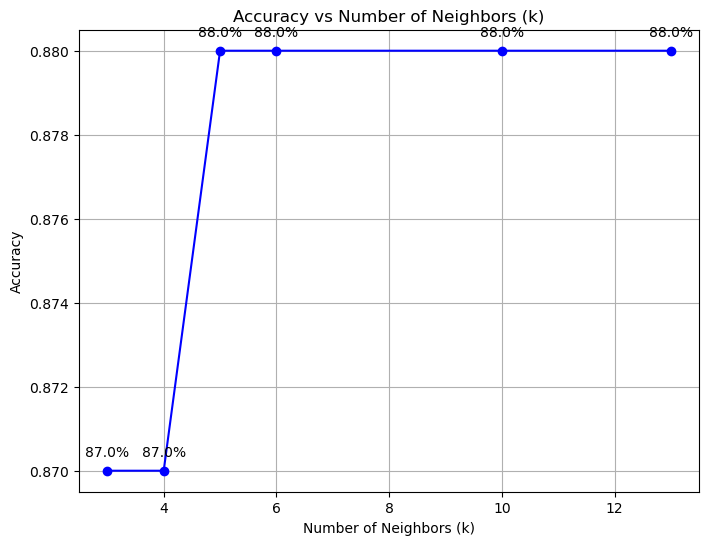

In [9]:
# Graphique de l'accuracy en fonction de la valeur de k, sans SMOTE

# Valeurs de k et leurs accuracies associées
k_values = [3, 4, 5, 6, 10, 13]
accuracies = [0.87, 0.87, 0.88, 0.88, 0.88, 0.88]  # Accuracy sous forme de pourcentage (0.87 -> 87%)

# Tracer le graphique
plt.figure(figsize=(8, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b')

# Ajouter des labels et un titre
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Neighbors (k)")

# Afficher les valeurs de l'accuracy à chaque point
for i, txt in enumerate(accuracies):
    plt.annotate(f'{txt*100:.1f}%', (k_values[i], accuracies[i]), textcoords="offset points", xytext=(0, 10), ha='center')

# Afficher le graphique
plt.grid(True)
plt.show()

Mieux de tester des valeurs de k impaires pour éviter les inégalités et donc les mauvaises classifications.

In [10]:
# # MET UNE PLOMBE ET FAIT TOUT BUGER
# # RandomizedSearchCV pour optimiser k
# param_dist = {
#     'n_neighbors': randint(1, 21),  # Recherche de k entre 1 et 20
#     'leaf_size': randint(10, 50),  # Recherche de la taille des feuilles de l'arbre (pour accélérer l'algorithme)
#     'p': [1, 2]  # p=1 correspond à la distance de Manhattan, p=2 à la distance Euclidienne
# }

# # RandomizedSearchCV
# random_search = RandomizedSearchCV(knn, param_distributions=param_dist, n_iter=50, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)

# # Entraînement du modèle
# random_search.fit(X_train, y_train)

# # Meilleurs paramètres trouvés
# best_params = random_search.best_params_
# print(f"Meilleurs paramètres trouvés : {best_params}")

# # Meilleur modèle
# best_knn = random_search.best_estimator_

In [11]:
#balancement données
#pourquoi l'augemntation des donénes, sur quoi excactment les algo travaillent car les données ne sont pas de même taille donc cest contre intuitif 
#point sur l'exblicabilité
#meilleurs : 0.852 sur données complètes

In [12]:
# # 📌 PCA pour visualiser en 2D
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_train)

# plt.figure(figsize=(8,6))
# sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_train, palette='viridis', alpha=0.7)
# plt.title("Visualisation PCA des données")
# plt.show()

In [13]:
# MET UNE PLOMBE ET FAIT TOUT BUGER
# # 📌 Optimisation de k avec GridSearchCV
# param_grid = {'n_neighbors': np.arange(1, 21)}
# grid_search = GridSearchCV(KNeighborsClassifier(algorithm='ball_tree'), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
# grid_search.fit(X_train, y_train)

# # 📌 Meilleur k
# best_k = grid_search.best_params_['n_neighbors']
# print(f"Meilleur k trouvé : {best_k}")

In [14]:
# # 📌 Tracer l'évolution de la précision selon k
# k_values = np.arange(1, 21)
# accuracy_values = [grid_search.cv_results_['mean_test_score'][i] for i in range(len(k_values))]

# plt.figure(figsize=(8,6))
# plt.plot(k_values, accuracy_values, marker='o', linestyle='dashed', color='b')
# plt.xlabel("Nombre de voisins (k)")
# plt.ylabel("Précision")
# plt.title("Évolution de la précision en fonction de k")
# plt.show()

In [15]:
# # 📌 Entraînement final avec le meilleur k
# knn = KNeighborsClassifier(n_neighbors=best_k)
# knn.fit(X_train, y_train)

# # 📌 Prédictions
# y_pred = knn.predict(X_test)

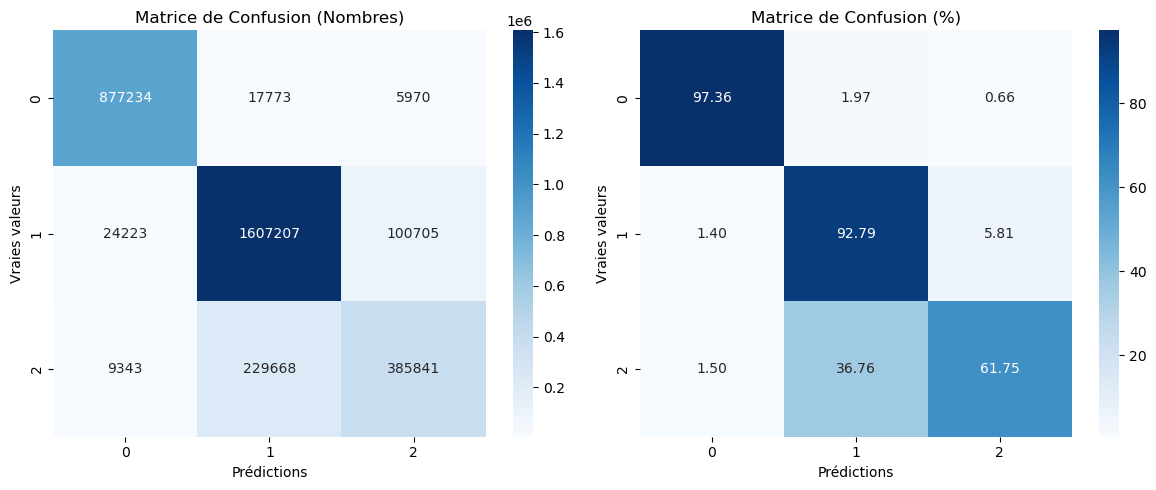

In [16]:
# 📌 Calcul de la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)

# 📌 Calcul de la matrice en pourcentage
conf_matrix_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

# 📌 Création des subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Deux colonnes

# 📌 Matrice de confusion classique
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y), ax=axes[0])
axes[0].set_title("Matrice de Confusion (Nombres)")
axes[0].set_xlabel("Prédictions")
axes[0].set_ylabel("Vraies valeurs")

# 📌 Matrice de confusion en pourcentage
sns.heatmap(conf_matrix_percent, annot=True, fmt=".2f", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y), ax=axes[1])
axes[1].set_title("Matrice de Confusion (%)")
axes[1].set_xlabel("Prédictions")
axes[1].set_ylabel("Vraies valeurs")

# 📌 Affichage
plt.tight_layout()
plt.show()


Endormi (0) est bien classé avec 876 773 bonnes prédictions, mais 24 204 erreurs (majoritairement vers "éveillé").
Éveillé (1) est bien détecté avec 1 578 790 bonnes prédictions, mais 153 345 erreurs (principalement vers "autre").
Autre (2) est moins bien détecté avec 403 216 bonnes prédictions, mais 221 636 erreurs (principalement vers "éveillé").

Le problème majeur concerne "autre (2)", qui est mal classé à 34.21% vers "éveillé".

--> Le modèle est performant pour distinguer le sommeil et l'éveil.
⚠️ Il a du mal avec la catégorie "autre", qui est souvent confondue avec "éveillé".

In [17]:
# 📌 Rapport de classification
print("Rapport de classification :")
print(classification_report(y_test, y_pred))

Rapport de classification :
              precision    recall  f1-score   support

           0       0.96      0.97      0.97    900977
           1       0.87      0.93      0.90   1732135
           2       0.78      0.62      0.69    624852

    accuracy                           0.88   3257964
   macro avg       0.87      0.84      0.85   3257964
weighted avg       0.88      0.88      0.88   3257964



Avec SMOTE :
precision    recall  f1-score   

           0       0.97      0.97      0.97    
           1       0.87      0.91      0.89   
           2       0.74      0.65      0.69 

In [20]:
import shap
# SHAP values - Explanation of model
X = pd.DataFrame(df)  # S'assurer que X est un DataFrame
X = X_train.sample(n=1000, random_state=42)  # Réduit la taille pour éviter un calcul trop long
explainer = shap.KernelExplainer(knn.predict_proba, X)
shap_values = explainer.shap_values(X_test)

# Visualize SHAP values (summary plot)
shap.summary_plot(shap_values, X_test)

# Visualize SHAP values for a single prediction (force plot)
shap.initjs()  # Initialize JavaScript visualization
shap.force_plot(explainer.expected_value[1], shap_values[1][0], X_test.iloc[0])

AttributeError: 'numpy.ndarray' object has no attribute 'sample'

In [ ]:
import shap
shap.initjs()
explainer = shap.KernelExplainer(knn.predict_proba, X_train)
shap_values = explainer.shap_values(X_test)

NameError: name 'X_sample_array' is not defined

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Échantillonnage pour éviter un temps de calcul trop long
X_sample = X_train.sample(100, random_state=42)  # Prenez un sous-échantillon pour accélérer
X_sample_array = X_sample.to_numpy()

# Création de l'explicateur SHAP basé sur KernelExplainer
explainer = shap.KernelExplainer(knn.predict_proba, X_sample_array)

# Calcul des valeurs SHAP sur un sous-échantillon de X_test
shap_values = explainer.shap_values(X_test.iloc[:50])  # Sur 50 observations

# Affichage de l'importance des features
shap.summary_plot(shap_values, X_test.iloc[:50])


AttributeError: 'numpy.ndarray' object has no attribute 'sample'

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
%matplotlib inline

import skater.core.explanations
from skater.core.explanations import Interpretation
from skater.model import InMemoryModel

ModuleNotFoundError: No module named 'skater'